* https://developer.apple.com/metal/tensorflow-plugin/
* https://www.youtube.com/watch?v=w2qlou7n7MA
* https://github.com/conda-forge/miniforge
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/install/tensorflow-install-mac-metal-jul-2021.ipynb
* https://github.com/jeffheaton/t81_558_deep_learning/blob/master/tensorflow-apple-metal.yml
* https://github.com/GPflow/GPflow
* `jupytext --to notebook regression.pct.py`

In [21]:
'''
# What version of Python do you have?
import sys

import tensorflow.keras
import pandas as pd
import sklearn as sk
import scipy as sp
import tensorflow as tf
#import tensorflow.compat.v2 as tf
import tensorflow_probability as tfp
import gpflow as gpf

print(f"Tensor Flow Version: {tf.__version__}")
print(f"Tensor Flow Probability: {tfp.__version__}")
print(f"Keras Version: {tensorflow.keras.__version__}")
print()
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}")
print(f"Scipy {sp.__version__}")
print(f"Scikit-Learn {sk.__version__}")
print(f"GPFlow {gpf.__version__}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")
'''

'\n# What version of Python do you have?\nimport sys\n\nimport tensorflow.keras\nimport pandas as pd\nimport sklearn as sk\nimport scipy as sp\nimport tensorflow as tf\n#import tensorflow.compat.v2 as tf\nimport tensorflow_probability as tfp\nimport gpflow as gpf\n\nprint(f"Tensor Flow Version: {tf.__version__}")\nprint(f"Tensor Flow Probability: {tfp.__version__}")\nprint(f"Keras Version: {tensorflow.keras.__version__}")\nprint()\nprint(f"Python {sys.version}")\nprint(f"Pandas {pd.__version__}")\nprint(f"Scipy {sp.__version__}")\nprint(f"Scikit-Learn {sk.__version__}")\nprint(f"GPFlow {gpf.__version__}")\ngpu = len(tf.config.list_physical_devices(\'GPU\'))>0\nprint("GPU is", "available" if gpu else "NOT AVAILABLE")\n'

In [22]:
pip install covasim gpflow

In [23]:
import covasim as cv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow as gpf
from gpflow.utilities import print_summary

# The lines below are specific to the notebook format
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

dtyp = np.float64
gpf.config.set_default_float(dtyp)

###
print("Tensorflow version " + tf.__version__)

try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
except ValueError:
  raise BaseException('ERROR: Not connected to a TPU runtime; please see the previous cell in this notebook for instructions!')

tf.config.experimental_connect_to_cluster(tpu)
tf.tpu.experimental.initialize_tpu_system(tpu)
tpu_strategy = tf.distribute.experimental.TPUStrategy(tpu)
###


tf.config.list_physical_devices('GPU')

Tensorflow version 2.8.0
Running on TPU  ['10.29.170.170:8470']
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.


INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.


INFO:tensorflow:Initializing the TPU system: grpc://10.29.170.170:8470


INFO:tensorflow:Initializing the TPU system: grpc://10.29.170.170:8470


INFO:tensorflow:Finished initializing TPU system.


...

INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU_SYSTEM:0, TPU_SYSTEM, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU_SYSTEM:0, TPU_SYSTEM, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:XLA_CPU:0, XLA_CPU, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:XLA_CPU:0, XLA_CPU, 0, 0)


[]

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.53 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.61 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.69 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.75 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.82 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.92 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (1.05 s)  •••••••••••••••••••• 100%

Simulation summary:
       12,730 cumulative infections
          596 cumulative reinfections
       10,182 cumulative infectious
        6,395 cumulative symptomatic cases
          386 cumulative severe cases
          114 cumulative critical cases
        5,159 cumulative recoveries
           14 cumulative deaths
            0 cumulative tests
            0 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
            0 cumulative vaccine dose

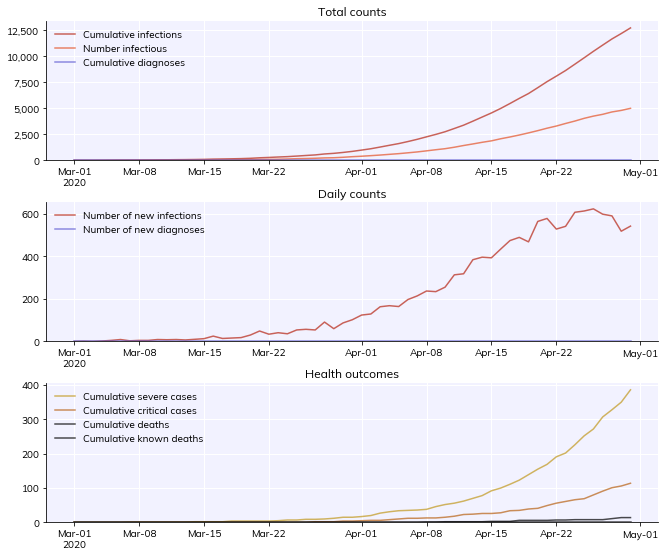

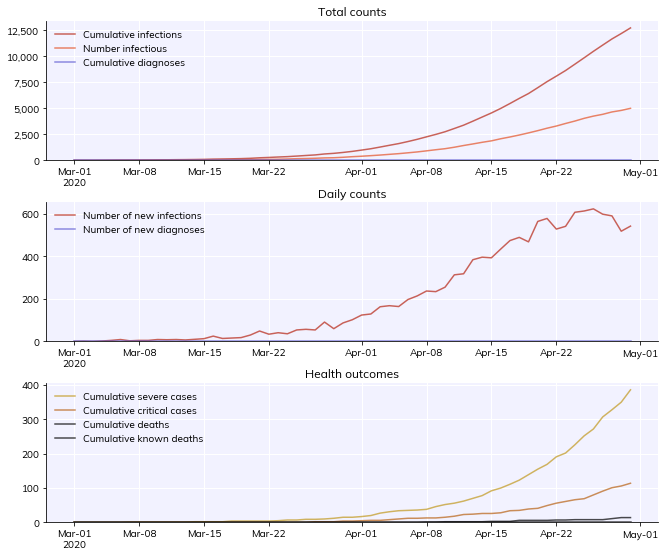

In [24]:
sim = cv.Sim()
sim.run().plot()

In [25]:
betas = np.logspace(-2.25, -1.25, 100).astype(dtyp)
sims = []
for i, beta in enumerate(betas):
    sim = cv.Sim(beta=beta, rand_seed=i, label=f'Beta = {beta}')
    sims.append(sim)
msim = cv.MultiSim(sims, reseed=True)
msim.run()

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
  Running "Beta = 0.007608746786030617": 2020-03-01 ( 0/60) (0.65 s)  ———————————————————— 2%
  Running "Beta = 0.007608746786030617": 2020-03-11 (10/60) (0.73 s)  •••————————————————— 18%
  Running "Beta = 0.005623413251903491": 2020-03-01 ( 0/60) (0.80 s)  ———————————————————— 2%
  Running "Beta = 0.005623413251903491": 2020-03-11 (10/60) (0.95 s)  •••————————————————— 18%
  Running "Beta = 0.007608746786030617": 2020-03-21 (20/60) (0.89 s)  ••••••—————————————— 34%
  Running "Beta = 0.007608746786030617": 2020-03-31 (30/60) (1.00 s)  ••••••••••—————————— 51%
  Running "Beta = 0.005623413251903491": 2020-03-21 (20/60) (1.13 s)  ••••••—————————————— 34%
  Running "Beta = 0.007608746786030617": 2020-04-10 (40/60) (1.17 s)  •••••••••••••——————— 67%
  Running "Beta = 0.005623413251903491": 2020-03-31 (30/60) (1.29 s)  ••••••••••—————————— 51%
  Running "Beta = 0.007608746786030617": 2020-04-20 (

MultiSim("Beta = 0.005623413251903491"; n_sims: 100; base: Sim("Beta = 0.005623413251903491"; 2020-03-01 to 2020-04-30; pop: 20000 random; epi: not run))

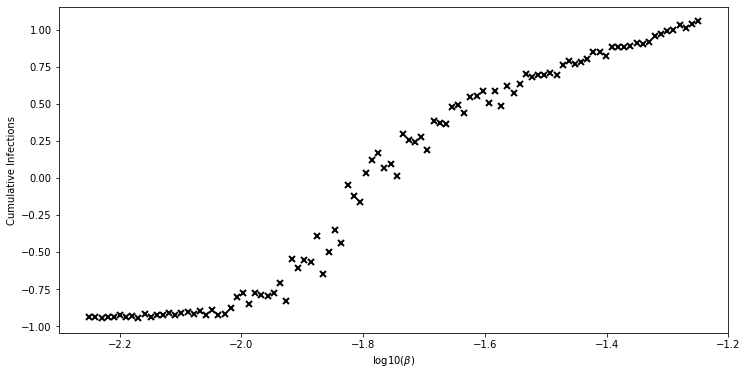

In [26]:
X = np.array(np.log10([s.pars['beta'] for s in msim.sims])).reshape(-1, 1).astype(dtyp)
Y = np.array([s.results['cum_infections'][-1] for s in msim.sims]).reshape(-1, 1).astype(dtyp)

Y = Y-Y.mean()
Y = 2 * Y / (Y.max() - Y.min())

f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_xlabel(r'$\log10(\beta$)');
ax.set_ylabel('Cumulative Infections');

In [27]:
k = gpf.kernels.Matern52()
print_summary(k)

╒═══════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                  │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═══════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ Matern52.variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
├───────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ Matern52.lengthscales │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
╘═══════════════════════╧═══════════╧═════════════╧═════════╧═════════════╧═════════╧═════════╧═════════╛


In [28]:
m = gpf.models.GPR(data=(X, Y), kernel=k, mean_function=None)
m.likelihood.variance.assign(1)
m.kernel.lengthscales.assign(0.3)
m.kernel.variance.assign(1)
print_summary(m)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │     1   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │     0.3 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │     1   │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

In [29]:
opt = gpf.optimizers.Scipy()

opt_logs = opt.minimize(m.training_loss, m.trainable_variables, options=dict(maxiter=10000))
print_summary(m)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.703584   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.464417   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 0.00346416 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧════

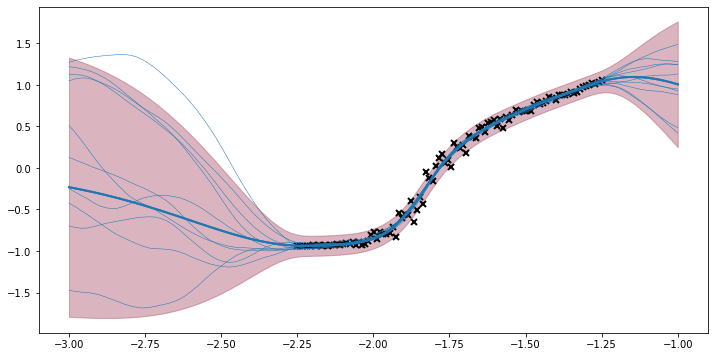

In [30]:
## generate test points for prediction
#xx = np.linspace(-0.1, 1.1, 100).reshape(100, 1)  # test points must be of shape (N, D)
xx = np.log10(np.logspace(-3, -1, 100)).reshape(100, 1).astype(dtyp)  # test points must be of shape (N, D)

## predict mean and variance of latent GP at test points
mean_f, var_f = m.predict_y(xx)
mean_y, var_y = m.predict_y(xx)

## generate 10 samples from posterior
tf.random.set_seed(1)  # for reproducibility
samples = m.predict_f_samples(xx, 10)  # shape (10, 100, 1)

## plot
plt.figure(figsize=(12, 6))
plt.plot(X, Y, "kx", mew=2)
def plot(mu, sig, col):
    plt.plot(xx, mu, "C0", lw=2)
    plt.fill_between(
        xx[:, 0],
        mu[:, 0] - 1.96 * np.sqrt(sig[:, 0]),
        mu[:, 0] + 1.96 * np.sqrt(sig[:, 0]),
        color=col,
        alpha=0.2,
    )
plot(mean_f, var_f, 'C0')
plot(mean_y, var_y, 'r')

plt.plot(xx, samples[:, :, 0].numpy().T, "C0", linewidth=0.5);
#_ = plt.xlim(-0.1, 1.1)

In [42]:
likelihood = gpf.likelihoods.HeteroskedasticTFPConditional(
    distribution_class=tfp.distributions.Normal,  # Gaussian Likelihood
    scale_transform=tfp.bijectors.Exp(),  # Exponential Transform
)

print(f"Likelihood's expected latent_dim: {likelihood.latent_dim}")

Likelihood's expected latent_dim: 2


In [43]:
def plot_distribution(X, Y, loc, scale):
    plt.figure(figsize=(15, 5))
    x = X.squeeze()
    for k in (1, 2):
        lb = (loc - k * scale).squeeze()
        ub = (loc + k * scale).squeeze()
        plt.fill_between(x, lb, ub, color="silver", alpha=1 - 0.05 * k ** 3)
    plt.plot(x, lb, color="silver")
    plt.plot(x, ub, color="silver")
    plt.plot(X, loc, color="black")
    plt.scatter(X, Y, color="gray", alpha=0.8)
    plt.show()
    plt.close()

In [44]:
kernel = gpf.kernels.SeparateIndependent(
    [
        gpf.kernels.SquaredExponential(),  # This is k1, the kernel of f1
        gpf.kernels.SquaredExponential(),  # this is k2, the kernel of f2
    ]
)
# The number of kernels contained in gpf.kernels.SeparateIndependent must be the same as likelihood.latent_dim

In [45]:
M = 25  # Number of inducing variables for each f_i

# Initial inducing points position Z
Z = np.linspace(X.min(), X.max(), M)[:, None]  # Z must be of shape [M, 1]
inducing_variable = gpf.inducing_variables.SeparateIndependentInducingVariables(
    [
        gpf.inducing_variables.InducingPoints(Z),  # This is U1 = f1(Z1)
        gpf.inducing_variables.InducingPoints(Z),  # This is U2 = f2(Z2)
    ]
)

name,class,transform,prior,trainable,shape,dtype,value
SVGP.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[1].variance,Parameter,Softplus,,True,(),float64,1.0
SVGP.kernel.kernels[1].lengthscales,Parameter,Softplus,,True,(),float64,1.0
SVGP.inducing_variable.inducing_variable_list[0].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.25...
SVGP.inducing_variable.inducing_variable_list[1].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.25...
SVGP.q_mu,Parameter,Identity,,True,"(25, 2)",float64,"[[0., 0...."
SVGP.q_sqrt,Parameter,FillTriangular,,True,"(2, 25, 25)",float64,"[[[1., 0., 0...."


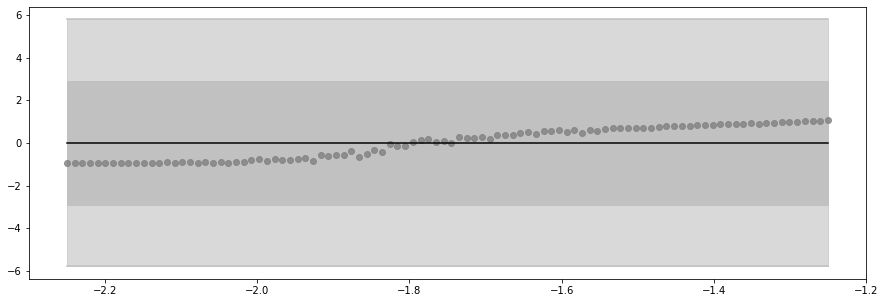

In [46]:
model = gpf.models.SVGP(
    kernel=kernel,
    likelihood=likelihood,
    inducing_variable=inducing_variable,
    num_latent_gps=likelihood.latent_dim,
)
'''

model = gpf.models.VGP(
    data=(X,Y),
    kernel=kernel,
    likelihood=likelihood,
    num_latent_gps=likelihood.latent_dim,
)
'''

#model.kernel.kernels[0].lengthscales.assign(1e6)
#model.kernel.kernels[0].variance.assign(1)
#model.kernel.kernels[1].lengthscales.assign(0.0002)
#model.kernel.kernels[1].variance.assign(10)

display(model)

'''
from gpflow.optimizers import NaturalGradient
from gpflow import set_trainable
from gpflow.ci_utils import ci_niter
natgrad = NaturalGradient(gamma=1.0)
adam = tf.optimizers.Adam()

set_trainable(model.q_mu, False)
set_trainable(model.q_sqrt, False)

for _ in range(ci_niter(1000)):
    natgrad.minimize(model.training_loss, [(model.q_mu, model.q_sqrt)])
    adam.minimize(model.training_loss, model.trainable_variables)
'''

Ymean, Yvar = model.predict_y(Xnew=X)#, full_cov=False)
Ymean = Ymean.numpy().squeeze()
Ystd = tf.sqrt(Yvar).numpy().squeeze()
plot_distribution(X, Y, Ymean, Ystd)

In [47]:
data = (X, Y)
loss_fn = model.training_loss_closure(data)

gpf.utilities.set_trainable(model.q_mu, False)
gpf.utilities.set_trainable(model.q_sqrt, False)

variational_vars = [(model.q_mu, model.q_sqrt)]
natgrad_opt = gpf.optimizers.NaturalGradient(gamma=0.1)

adam_vars = model.trainable_variables
adam_opt = tf.optimizers.Adam(0.01)


@tf.function
def optimisation_step():
    natgrad_opt.minimize(loss_fn, variational_vars)
    adam_opt.minimize(loss_fn, adam_vars)

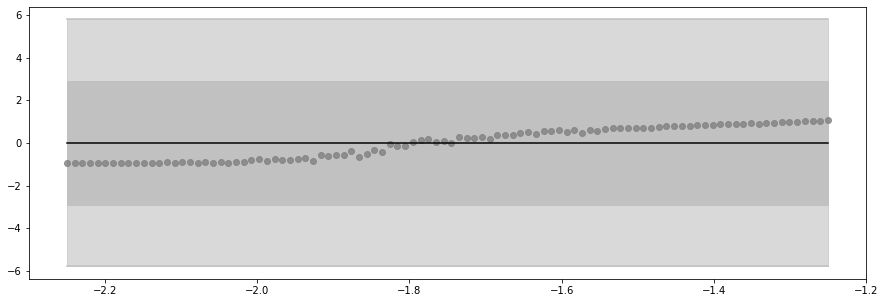

Epoch 1000 - Loss: -120.7768


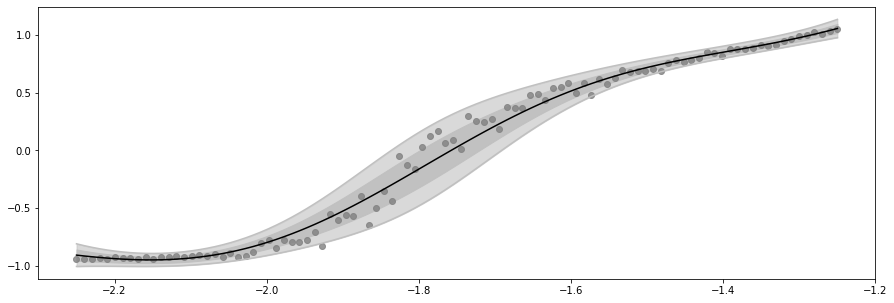

Epoch 2000 - Loss: -124.4278


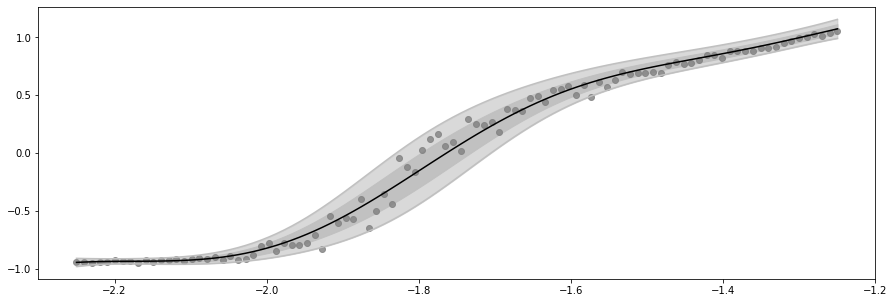

Epoch 3000 - Loss: -146.4462


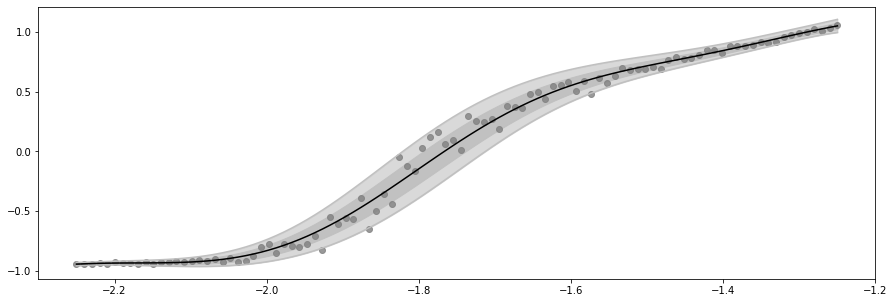

Epoch 4000 - Loss: -143.9165


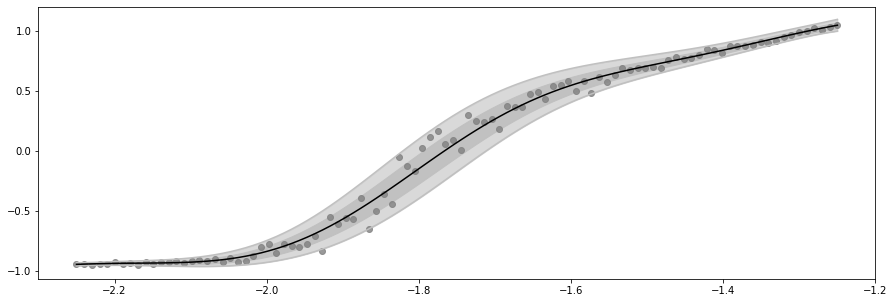

Epoch 5000 - Loss: -151.4914


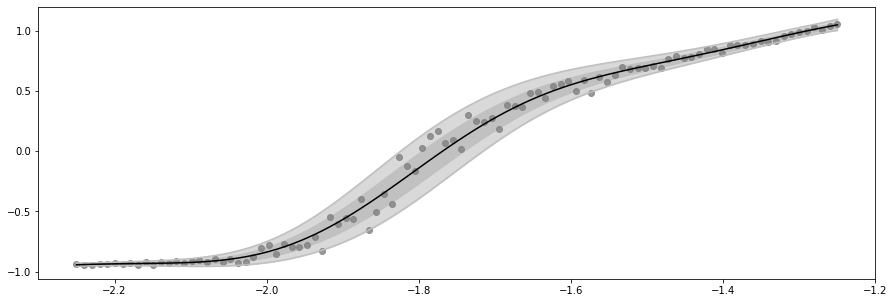

Epoch 6000 - Loss: -147.8541


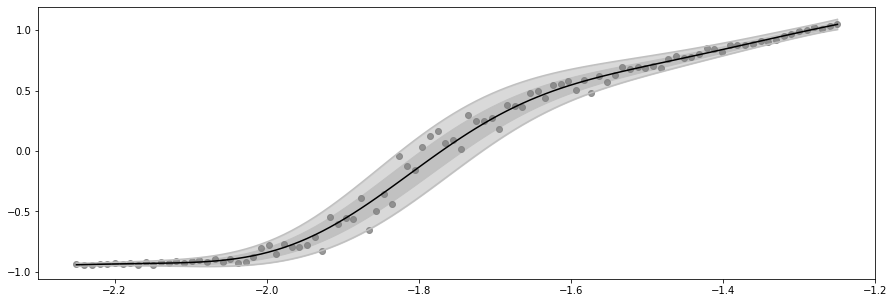

Epoch 7000 - Loss: -157.6208


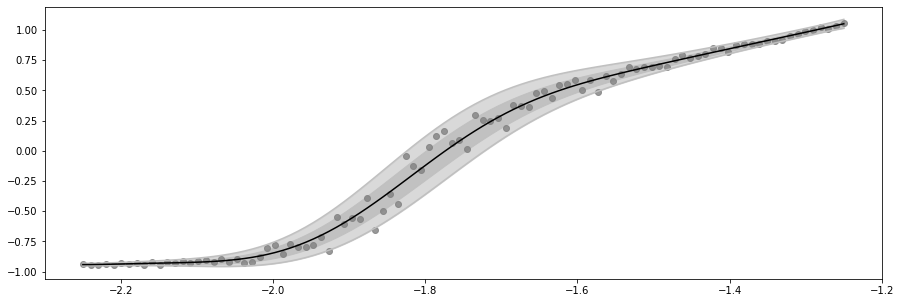

Epoch 8000 - Loss: -155.4698


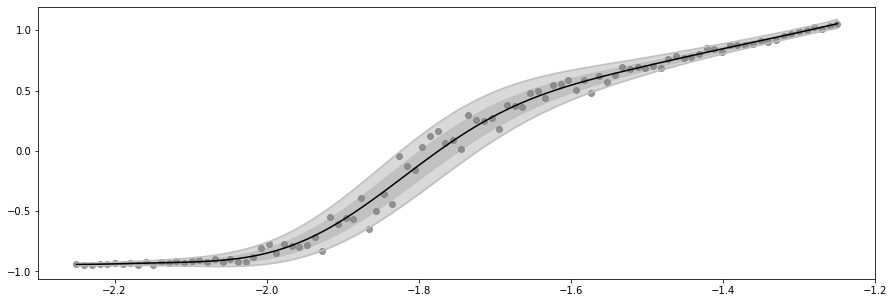

Epoch 9000 - Loss: -158.5103


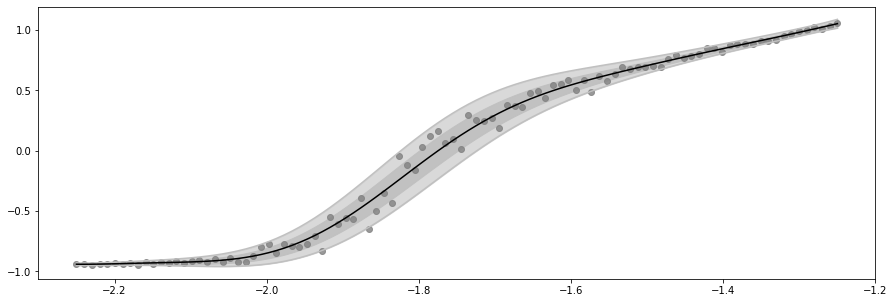

Epoch 10000 - Loss: -158.1588


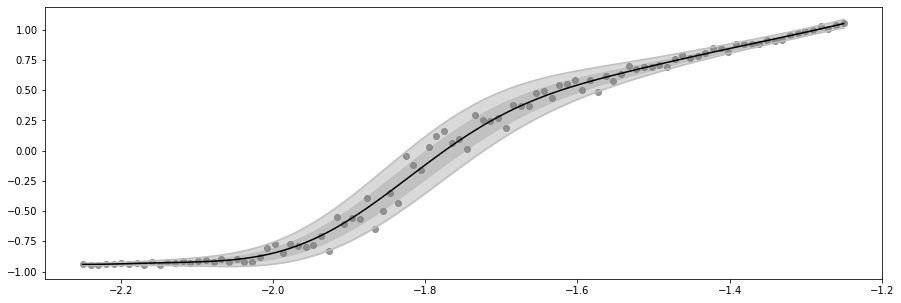

name,class,transform,prior,trainable,shape,dtype,value
SVGP.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,0.8046984728473082
SVGP.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,(),float64,0.23310329530343352
SVGP.kernel.kernels[1].variance,Parameter,Softplus,,True,(),float64,32.261705485690165
SVGP.kernel.kernels[1].lengthscales,Parameter,Softplus,,True,(),float64,0.461225499640185
SVGP.inducing_variable.inducing_variable_list[0].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.24870824...
SVGP.inducing_variable.inducing_variable_list[1].Z,Parameter,Identity,,True,"(25, 1)",float64,[[-2.4820274...
SVGP.q_mu,Parameter,Identity,,False,"(25, 2)",float64,"[[-1.04851535e+00, -1.08797416e+00..."
SVGP.q_sqrt,Parameter,FillTriangular,,False,"(2, 25, 25)",float64,"[[[2.84206312e-03, 0.00000000e+00, 0.00000000e+00..."


In [48]:
epochs = 10000 # 100
log_freq = 1000 # 20

def p():
    Ymean, Yvar = model.predict_y(X)
    Ymean = Ymean.numpy().squeeze()
    Ystd = tf.sqrt(Yvar).numpy().squeeze()
    plot_distribution(X, Y, Ymean, Ystd)

p()
for epoch in range(1, epochs + 1):
    optimisation_step()

    # For every 'log_freq' epochs, print the epoch and plot the predictions against the data
    if epoch % log_freq == 0 and epoch > 0:
        print(f"Epoch {epoch} - Loss: {loss_fn().numpy() : .4f}")
        p()

model